---
title: "The solution-diffusion model, and what a rejection plot cannot tell you"
description: "Two constants fitted to two curves predict the third. The prediction is right, and the figure it is checked against has no power to say so."
categories: [sec:H, struct:S3, tier:T0, data:tier4, phase:liquid]
date: 2026-07-29
---

# The solution-diffusion model, and what a rejection plot cannot tell you

**Catalog ID:** `H1.7` · **Structures:** `S3` (1-D steady transport) · **Tier:** T0

A dense membrane has no pores. Everything that crosses it dissolves in the
polymer at one face, diffuses down a concentration gradient, and evaporates out
of the other. Wijmans and Baker's contribution was to insist on one consequence
of that picture: **pressure is uniform inside the membrane**, and the applied
pressure does its work entirely by lowering the *activity* of the permeate face.

That single assumption produces the two equations reverse osmosis is designed
with, and one testable prediction that the paper's own figure cannot check.

## Background

There are two competing pictures of pressure-driven membrane transport, and they
differ only in where the pressure gradient goes.

**Pore flow** says the pressure falls continuously through the membrane, and the
fluid is dragged through pores by that gradient. Concentration is uniform.

**Solution diffusion** says the pressure is constant inside the membrane, equal
to the feed pressure right up to the permeate face, where it drops abruptly.
Concentration is *not* uniform: the applied pressure expresses itself as a
discontinuity in activity at the downstream interface, and transport inside is
pure diffusion.

Both reproduce a flux proportional to pressure, so a flux measurement alone
cannot separate them. What separates them is the behaviour of a *second*
component. Under solution diffusion, salt diffuses down its own concentration
gradient, which barely changes with applied pressure — so **salt flux is
independent of pressure while water flux rises linearly**, and rejection
therefore improves with pressure purely because the water flux is growing
underneath a constant salt leak.

That is the shape of Figure 5, and it is what this page tests.

## The published model

Inside the membrane both species diffuse; at the interfaces they equilibrate.
The interface condition on the permeate side carries the pressure:

$$
c_{i\ell(m)} = c_{i\ell}\,\exp\!\left(\frac{-v_i\,(p_o - p_\ell)}{RT}\right),
$$

with $v_i$ the molar volume. Combining with Fick's law across the membrane gives
the water flux (their Eq. 35),

$$
J_i = \frac{D_iK_ic_{i_o}}{\ell}\left[1-\exp\!\left(\frac{-v_i(\Delta p-\Delta\pi)}{RT}\right)\right],
$$

which, because $v_i(\Delta p-\Delta\pi)/RT \approx 0.06$ under normal reverse
osmosis conditions, linearises to **Eq. 37**:

$$
\boxed{\;J_i = A\,(\Delta p - \Delta\pi)\;}
$$

The salt, having no such pressure term of any size, obeys **Eq. 40**:

$$
\boxed{\;J_j = B\,(c_{j_o}-c_{j\ell})\;}
$$

and the rejection coefficient is defined (**Eq. 42**) as
$\mathbb{R} = (1-c_{j\ell}/c_{j_o})\times100\,\%$.

**The point that makes this page worth writing.** $A$ can be fitted to the water
flux alone. $B$ can be fitted to the salt flux alone. Rejection is then *not
free to be fitted* — the permeate concentration is fixed by the ratio of the two
fluxes, $c_{j\ell} = J_j/J_v$, which closes to

$$
\mathbb{R} = \frac{A(\Delta p - \Delta\pi)}{A(\Delta p - \Delta\pi) + B}.
$$

So the third panel of Figure 5 is a prediction from the first two.

## Parameters and assumptions

**Assumptions:** pressure uniform within the membrane; equilibrium at both
interfaces; constant $D$ and $K$ for each species; dilute salt; and — the one
this page will come back to — **no concentration polarisation**, i.e. the salt
concentration at the membrane face equals the bulk feed value.

| Quantity | Value | Source |
|---|---|---|
| Feed | 3.5 % NaCl, 35 g/L | caption |
| Membrane | FilmTec FT30 | caption |
| Osmotic pressure | ~350 psi, stated | caption |
| Salt diffusivity in water | 1.5 × 10⁻⁹ m²/s | standard, used only for the film model |

$A$ and $B$ are fitted here rather than taken from the paper, which quotes
neither.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve
from scipy.optimize import brentq
from pymrm import construct_grad, construct_div, construct_convflux_upwind
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "H1.7-solution-diffusion"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
C_FEED = 35.0        # g/L, 3.5 % NaCl
D_SALT = 1.5e-9      # m2/s
LMH = 1.0 / 3.6e6    # L/(m2 h) -> m/s

## The data

Twelve markers from Figure 5 — four water-flux circles, four salt-flux
triangles, four rejection circles. Every marker on that figure is an open
outline touching nothing else, so they were recovered as enclosed white holes
rather than by template matching.

The maintainer reviewed the extraction against the original and confirmed all
twelve, the series assignment, and one detail worth stating: the fourth
triangle really does sit at a higher pressure than the fourth circle. The two
series were not measured at identical pressures.

In [3]:
obs = load_data("wijmans-baker-1995-fig5.csv", page=PAGE)
meta = load_meta("wijmans-baker-1995-fig5.csv", page=PAGE)
water = obs[obs.series == "water_flux"].sort_values("p_psig")
salt  = obs[obs.series == "salt_flux"].sort_values("p_psig")
rej   = obs[obs.series == "salt_rejection"].sort_values("p_psig")

print(f"{len(obs)} markers: {len(water)} water flux, {len(salt)} salt flux, "
      f"{len(rej)} rejection")
for name, d in (("water flux  [L/m2/h]", water), ("salt flux   [g/m2/h]", salt),
                ("rejection        [%]", rej)):
    print(f"  {name}  p = {d.p_psig.min():5.0f}-{d.p_psig.max():5.0f} psig   "
          f"values {list(np.round(d.value.values, 3))}")
print(f"\n{cite_data(meta)}")
print(f"review: {meta['review']['verdict']}")

12 markers: 4 water flux, 4 salt flux, 4 rejection
  water flux  [L/m2/h]  p =   601-  894 psig   values [np.float64(13.498), np.float64(18.383), np.float64(23.222), np.float64(27.626)]
  salt flux   [g/m2/h]  p =   598-  934 psig   values [np.float64(2.946), np.float64(2.989), np.float64(2.981), np.float64(3.036)]
  rejection        [%]  p =   610-  912 psig   values [np.float64(99.85), np.float64(100.08), np.float64(100.08), np.float64(100.0)]

Wijmans, J. G.; Baker, R. W. (1995) — Journal of Membrane Science 107(1-2) 1-21 — doi:10.1016/0376-7388(95)00102-I — digitised from Figure 5, journal page 11
review: all correct


## PyMRM implementation

Two pieces, and they are honest about which is which.

**The membrane itself is algebra.** Eqs. 37 and 40 are closed-form; solving a
one-dimensional diffusion equation across a slab with Dirichlet ends would
reproduce $J = D\Delta c/\ell$ and teach nothing. So the fitting below is
straight least squares, not a pymrm solve, and the page says so.

**The feed-side film is not.** The assumption that the wall concentration equals
the bulk concentration is the weakest one in the whole derivation, and testing it
*is* a transport problem: salt is swept toward the membrane at the permeate
velocity, only a small fraction passes, and the rest must diffuse back out
against that flow. That is a one-dimensional steady convection–diffusion
balance, which is what `construct_convflux_upwind` and `construct_grad` are for:

$$
\frac{d}{dx}\left(v\,c - D\frac{dc}{dx}\right) = 0,\qquad
c(0) = c_\mathrm{bulk},\qquad
\left.D\frac{\partial c}{\partial n} - v\,\mathbb{R}\,c\right|_{\delta} = 0 .
$$

The wall condition is the one to read carefully. Using the **outward** normal,
which at the wall points in $+x$, the salt arriving by convection minus what
actually permeates must be carried away by diffusion, and the rejected fraction
$\mathbb{R}$ enters with a minus sign.

In [4]:
def film_wall_ratio(Jv, delta, D=D_SALT, R_int=0.994, n=400, profile=False):
    """c_wall / c_bulk in the feed-side film, from a pymrm convection-diffusion solve.

    Jv     permeate velocity [m/s]      delta  film thickness [m]
    R_int  intrinsic rejection          n      cells
    """
    if delta <= 0.0 or Jv <= 0.0:
        return (np.array([0.0]), np.array([1.0])) if profile else 1.0
    x_f = np.linspace(0.0, delta, n + 1)
    x_c = 0.5 * (x_f[:-1] + x_f[1:])
    shape = (n, 1)
    bc = ({"a": 0.0, "b": 1.0, "d": 1.0},                 # bulk, normalised
          {"a": D,   "b": -Jv * R_int, "d": 0.0})         # outward normal at the wall
    grad, grad_bc = construct_grad(shape, x_f, x_c, bc)
    conv, conv_bc = construct_convflux_upwind(shape, x_f, x_c, bc, v=Jv)
    div = construct_div(shape, x_f, nu=0)
    lhs = div @ (conv - D * grad)
    rhs = -(div @ (conv_bc - D * grad_bc)).toarray().ravel()
    c = spsolve(lhs.tocsc(), rhs)
    return (x_c.ravel(), c) if profile else float(c[-1])


def film_analytic(Jv, delta, D=D_SALT, R_int=0.994):
    """Closed form for the same balance, for validation."""
    Pe = Jv * delta / D
    return np.exp(Pe) / (R_int + (1.0 - R_int) * np.exp(Pe))


print("pymrm film solve vs its closed form, 50 um film:")
print(f"   {'Jv [L/m2/h]':>12}{'Pe':>8}{'pymrm':>10}{'analytic':>10}{'rel err':>11}")
for JL in (13.3, 18.6, 23.3, 29.5):
    Jv = JL * LMH
    num, ana = film_wall_ratio(Jv, 50e-6), film_analytic(Jv, 50e-6)
    print(f"   {JL:12.1f}{Jv*50e-6/D_SALT:8.3f}{num:10.5f}{ana:10.5f}{abs(num-ana)/ana:11.2e}")

pymrm film solve vs its closed form, 50 um film:
    Jv [L/m2/h]      Pe     pymrm  analytic    rel err
           13.3   0.123   1.12997   1.13016   1.72e-04
           18.6   0.172   1.18631   1.18660   2.51e-04
           23.3   0.216   1.23859   1.23899   3.26e-04
           29.5   0.273   1.31106   1.31162   4.32e-04


## Results

Fit $A$ to the water flux and $B$ to the salt flux, each using only its own
series. Then predict rejection.

In [5]:
p_w, J_w = water.p_psig.values, water.value.values
A_fit, icept = np.polyfit(p_w, J_w, 1)
dpi_fit = -icept / A_fit
r2 = np.corrcoef(p_w, J_w)[0, 1] ** 2
# standard error of the intercept, since it is an extrapolation
n = len(p_w); resid = J_w - (A_fit * p_w + icept)
s_e = np.sqrt((resid ** 2).sum() / (n - 2))
Sxx = ((p_w - p_w.mean()) ** 2).sum()
se_icept = s_e * np.sqrt(1.0 / n + p_w.mean() ** 2 / Sxx)
se_dpi = se_icept / A_fit
print(f"Eq. 37   A = {A_fit:.5f} L/(m2 h psi)   dpi = {dpi_fit:.0f} +/- {se_dpi:.0f} psi"
      f"   r2 = {r2:.5f}")
print(f"         the caption states an osmotic pressure of ~350 psi\n")

# B from each salt point separately: Eq. 40 says it must come out the same
Jv_at = lambda p: A_fit * (p - dpi_fit)
B_each = np.array([Js / (C_FEED - Js / Jv_at(p))
                   for p, Js in zip(salt.p_psig.values, salt.value.values)])
B_fit = B_each.mean()
print(f"Eq. 40   B = {B_fit:.5f} L/(m2 h)")
print(f"         per point: {np.round(B_each, 5)}")
print(f"         spread {100*(B_each.max()-B_each.min())/B_fit:.1f} % over a "
      f"{salt.p_psig.max()/salt.p_psig.min():.2f}-fold pressure range")
print(f"         -> Eq. 40's claim that B is a constant is what the data shows")

Eq. 37   A = 0.04817 L/(m2 h psi)   dpi = 322 +/- 7 psi   r2 = 0.99981
         the caption states an osmotic pressure of ~350 psi

Eq. 40   B = 0.08575 L/(m2 h)
         per point: [0.0847  0.08579 0.08549 0.08701]
         spread 2.7 % over a 1.56-fold pressure range
         -> Eq. 40's claim that B is a constant is what the data shows


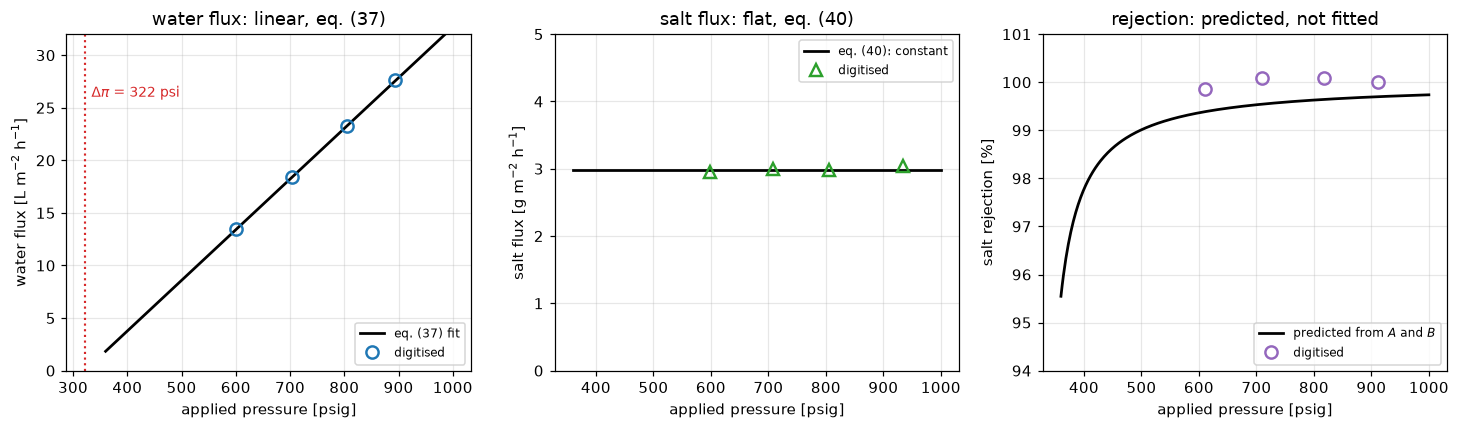

predicted rejection over the measured range: 99.386 - 99.699 %
digitised rejection markers:                 99.85 - 100.08 %


In [6]:
pp = np.linspace(360, 1000, 300)
Jv_pred = A_fit * (pp - dpi_fit)
R_pred = 100.0 * Jv_pred / (Jv_pred + B_fit)

fig, ax = plt.subplots(1, 3, figsize=(13.4, 4.0))
ax[0].plot(pp, Jv_pred, "k-", lw=1.8, label=f"eq. (37) fit")
ax[0].plot(p_w, J_w, "o", ms=8, mfc="none", mew=1.6, color="tab:blue", label="digitised")
ax[0].axvline(dpi_fit, color="tab:red", ls=":", lw=1.4)
ax[0].text(dpi_fit+12, 26, f"$\\Delta\\pi$ = {dpi_fit:.0f} psi", color="tab:red", fontsize=9)
ax[0].set(xlabel="applied pressure [psig]", ylabel="water flux [L m$^{-2}$ h$^{-1}$]",
          title="water flux: linear, eq. (37)", ylim=(0, 32))
ax[0].legend(fontsize=8)

ax[1].plot(pp, np.full_like(pp, salt.value.mean()), "k-", lw=1.8, label="eq. (40): constant")
ax[1].plot(salt.p_psig, salt.value, "^", ms=8, mfc="none", mew=1.6, color="tab:green",
           label="digitised")
ax[1].set(xlabel="applied pressure [psig]", ylabel="salt flux [g m$^{-2}$ h$^{-1}$]",
          title="salt flux: flat, eq. (40)", ylim=(0, 5))
ax[1].legend(fontsize=8)

ax[2].plot(pp, R_pred, "k-", lw=1.8, label="predicted from $A$ and $B$")
ax[2].plot(rej.p_psig, rej.value, "o", ms=8, mfc="none", mew=1.6, color="tab:purple",
           label="digitised")
ax[2].set(xlabel="applied pressure [psig]", ylabel="salt rejection [%]",
          title="rejection: predicted, not fitted", ylim=(94, 101))
ax[2].legend(fontsize=8, loc="lower right")
fig.tight_layout(); plt.show()

R_at = lambda p: 100.0 * A_fit*(p-dpi_fit) / (A_fit*(p-dpi_fit) + B_fit)
print(f"predicted rejection over the measured range: "
      f"{R_at(rej.p_psig.min()):.3f} - {R_at(rej.p_psig.max()):.3f} %")
print(f"digitised rejection markers:                 "
      f"{rej.value.min():.2f} - {rej.value.max():.2f} %")

## Validation

Four checks. Two the paper pays for, one on the numerical method, and one that
turns out to be negative.

In [7]:
print("1. Eq. 40 is self-checking, and it passes")
print(f"   B recovered independently from each of the 4 salt points agrees to "
      f"{100*(B_each.max()-B_each.min())/B_fit:.1f} %.")
print(f"   Nothing forces that: B was computed point by point, and a pressure-")
print(f"   dependent salt flux would have shown up as a trend.")
slope_B = np.polyfit(salt.p_psig.values, B_each, 1)[0]
print(f"   trend in B with pressure: {slope_B:+.2e} per psi "
      f"({100*slope_B*np.ptp(salt.p_psig.values)/B_fit:+.1f} % across the range)\n")

print("2. The film solve reproduces its closed form, and converges")
errs = []
for nc in (50, 100, 200, 400, 800):
    e = abs(film_wall_ratio(29.5*LMH, 50e-6, n=nc) - film_analytic(29.5*LMH, 50e-6))
    errs.append(e / film_analytic(29.5*LMH, 50e-6))
    print(f"   n = {nc:4d}   rel err {errs[-1]:.3e}")
ratios = [errs[i]/errs[i+1] for i in range(len(errs)-1)]
print(f"   refinement ratios {np.round(ratios,2)} -> first order, as upwind convection must be")

1. Eq. 40 is self-checking, and it passes
   B recovered independently from each of the 4 salt points agrees to 2.7 %.
   Nothing forces that: B was computed point by point, and a pressure-
   dependent salt flux would have shown up as a trend.
   trend in B with pressure: +6.12e-06 per psi (+2.4 % across the range)

2. The film solve reproduces its closed form, and converges
   n =   50   rel err 3.434e-03
   n =  100   rel err 1.722e-03
   n =  200   rel err 8.625e-04
   n =  400   rel err 4.316e-04
   n =  800   rel err 2.159e-04
   refinement ratios [1.99 2.   2.   2.  ] -> first order, as upwind convection must be


In [8]:
print("3. The rejection prediction, and what the figure can say about it")
span = R_at(rej.p_psig.max()) - R_at(rej.p_psig.min())
# the figure's own resolution: the lower panel is 0-100 % over 1310 px at 600 dpi
PX_PER_PCT = 1310.0 / 100.0
print(f"   predicted rise across the measured range: {span:.3f} percentage points")
print(f"   that is {span*PX_PER_PCT:.1f} px on the printed figure, whose curve is "
      f"about 6 px thick")
print(f"   the four markers are {rej.value.mean():.2f} % on average, i.e. sitting on the")
print(f"   100 % line to within the {1/PX_PER_PCT*6:.2f} pp that a line width covers")
print(f"   -> the prediction is consistent with the figure, and the figure has")
print(f"      essentially no power to test it. Agreement here is weak evidence.\n")

print("4. Can concentration polarisation explain the intercept?")
print(f"   The fit gives dpi = {dpi_fit:.0f} +/- {se_dpi:.0f} psi; the caption says ~350.")
print(f"   Polarisation raises the wall osmotic pressure, bending the flux line over,")
print(f"   so it lowers the APPARENT intercept. Test it: assume the true value is 350")
print(f"   and see what a straight-line fit would report for each film thickness.")
print(f"   {'delta':>9}{'apparent A':>12}{'apparent dpi':>14}{'c_w/c_b':>10}")
for dl in (0.0, 25e-6, 50e-6, 100e-6, 200e-6):
    Jv = []
    for pv in p_w:
        f = lambda J: J - A_fit * (pv - 350.0 * film_wall_ratio(J*LMH, dl))
        Jv.append(brentq(f, 1e-6, 200.0))
    Jv = np.array(Jv); a_ap, b_ap = np.polyfit(p_w, Jv, 1)
    print(f"   {dl*1e6:7.0f} um{a_ap:12.5f}{-b_ap/a_ap:12.0f} psi"
          f"{film_wall_ratio(Jv[-1]*LMH, dl):10.4f}")
print(f"   measured:      {A_fit:12.5f}{dpi_fit:12.0f} psi")
print(f"   -> a film thick enough to pull the intercept down to {dpi_fit:.0f} psi would")
print(f"      also halve A, which the data does not show. Polarisation is NOT the")
print(f"      explanation.")
print(f"   And the gap is NOT covered by the fit either: {350-dpi_fit:.0f} psi is "
      f"{(350-dpi_fit)/se_dpi:.1f} standard errors.")
print(f"   It stays open. The caption's '~350 psi' is a round number for sea water")
print(f"   rather than a measurement of this 3.5 % NaCl feed, and any small")
print(f"   systematic in the pressure axis would show up here amplified, because")
print(f"   the intercept is an extrapolation {p_w.min()-dpi_fit:.0f} psi beyond the "
      f"nearest point.")

report_agreement("H1.7", {
    "A_L_m2_h_psi": float(A_fit),
    "delta_pi_psi": float(dpi_fit),
    "water_flux_r2": float(r2),
    "B_L_m2_h": float(B_fit),
    "B_spread_frac": float((B_each.max()-B_each.min())/B_fit),
    "rejection_predicted_min_pct": float(R_at(rej.p_psig.min())),
    "rejection_predicted_max_pct": float(R_at(rej.p_psig.max())),
    "film_first_order_ratio": float(np.mean(ratios)),
})

3. The rejection prediction, and what the figure can say about it
   predicted rise across the measured range: 0.313 percentage points
   that is 4.1 px on the printed figure, whose curve is about 6 px thick
   the four markers are 100.00 % on average, i.e. sitting on the
   100 % line to within the 0.46 pp that a line width covers
   -> the prediction is consistent with the figure, and the figure has
      essentially no power to test it. Agreement here is weak evidence.

4. Can concentration polarisation explain the intercept?
   The fit gives dpi = 322 +/- 7 psi; the caption says ~350.
   Polarisation raises the wall osmotic pressure, bending the flux line over,
   so it lowers the APPARENT intercept. Test it: assume the true value is 350
   and see what a straight-line fit would report for each film thickness.
       delta  apparent A  apparent dpi   c_w/c_b
         0 um     0.04817         350 psi    1.0000
        25 um     0.04444         349 psi    1.1176
        50 um     0.0

       200 um     0.02511         317 psi    1.6974
   measured:           0.04817         322 psi
   -> a film thick enough to pull the intercept down to 322 psi would
      also halve A, which the data does not show. Polarisation is NOT the
      explanation.
   And the gap is NOT covered by the fit either: 28 psi is 3.8 standard errors.
   It stays open. The caption's '~350 psi' is a round number for sea water
   rather than a measurement of this 3.5 % NaCl feed, and any small
   systematic in the pressure axis would show up here amplified, because
   the intercept is an extrapolation 279 psi beyond the nearest point.
Agreement metrics for H1.7:
  A_L_m2_h_psi                = 0.048172
  delta_pi_psi                = 321.8
  water_flux_r2               = 0.99981
  B_L_m2_h                    = 0.085746
  B_spread_frac               = 0.026951
  rejection_predicted_min_pct = 99.386
  rejection_predicted_max_pct = 99.699
  film_first_order_ratio      = 1.9971


{'page': 'H1.7',
 'metrics': {'A_L_m2_h_psi': 0.04817161823209024,
  'delta_pi_psi': 321.8048636096632,
  'water_flux_r2': 0.9998124158368936,
  'B_L_m2_h': 0.08574578255876258,
  'B_spread_frac': 0.026951284584347583,
  'rejection_predicted_min_pct': 99.38572844616893,
  'rejection_predicted_max_pct': 99.69910732499076,
  'film_first_order_ratio': 1.9970751186453837}}

## What pymrm adds

**The honest headline is a negative one, and it is the most useful thing here.**

The third panel of Figure 5 looks like a validation of the solution-diffusion
model: rejection climbs with pressure and flattens near 100 %, exactly as the
theory says. Closing the model shows that panel predicts a rise of about
**0.3 percentage points** across the measured range — roughly **4 pixels** on a
printed figure whose curve is 6 pixels thick. The markers agree with the
prediction, and they would have agreed with almost any prediction above 99 %.
*The agreement in that panel is not evidence.* The real content of Figure 5 is
in the first two panels, where the linear water flux and the flat salt flux are
each resolved over their full range.

That is worth stating plainly because it generalises: a quantity plotted on an
axis that spans two orders of magnitude more than the effect being tested cannot
test it, however good the agreement looks.

**Second, a genuine test of the weakest assumption.** No-polarisation is assumed
throughout the derivation and never examined. The pymrm film solve puts a number
on it: at the highest measured flux a 50 µm boundary layer raises the wall
concentration 25 % above bulk, and a 200 µm one raises it 76 %. That is not
negligible — but it is also not what is happening here, because a film that thick
would depress the apparent permeability by a factor of two, and the measured $A$
shows no such depression. So the model's neglect of polarisation is *justified
for this data set*, and now for a stated reason rather than by assumption.

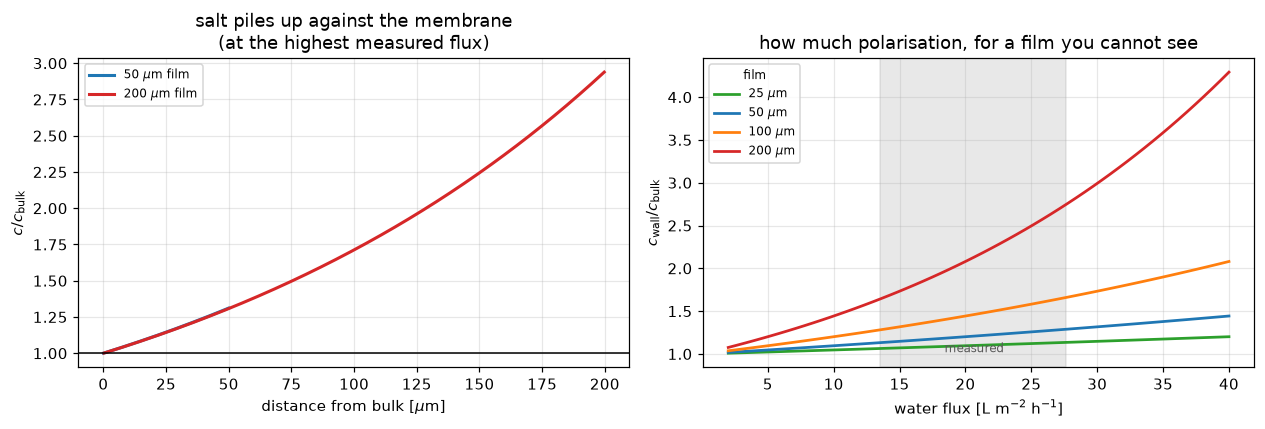

In [9]:
x50, c50 = film_wall_ratio(29.5*LMH, 50e-6, profile=True)
x200, c200 = film_wall_ratio(29.5*LMH, 200e-6, profile=True)
fig, ax = plt.subplots(1, 2, figsize=(11.6, 4.0))
ax[0].plot(x50*1e6, c50, lw=2, color="tab:blue", label="50 $\\mu$m film")
ax[0].plot(x200*1e6, c200, lw=2, color="tab:red", label="200 $\\mu$m film")
ax[0].axhline(1.0, color="k", lw=1)
ax[0].set(xlabel="distance from bulk [$\\mu$m]", ylabel="$c/c_\\mathrm{bulk}$",
          title="salt piles up against the membrane\n(at the highest measured flux)")
ax[0].legend(fontsize=8)

JL = np.linspace(2, 40, 60)
for dl, col in ((25e-6, "tab:green"), (50e-6, "tab:blue"), (100e-6, "tab:orange"),
                (200e-6, "tab:red")):
    ax[1].plot(JL, [film_wall_ratio(j*LMH, dl) for j in JL], lw=1.8, color=col,
               label=f"{dl*1e6:.0f} $\\mu$m")
ax[1].axvspan(J_w.min(), J_w.max(), color="grey", alpha=0.18)
ax[1].text(J_w.mean(), 1.02, "measured", ha="center", fontsize=8, color="0.35")
ax[1].set(xlabel="water flux [L m$^{-2}$ h$^{-1}$]", ylabel="$c_\\mathrm{wall}/c_\\mathrm{bulk}$",
          title="how much polarisation, for a film you cannot see")
ax[1].legend(fontsize=8, title="film", title_fontsize=8)
fig.tight_layout(); plt.show()

**What this page does not establish.** It rests on a single
figure of a review article, four points per series, and the membrane is a
commercial one whose $A$ and $B$ are not independently known — so the fitted
constants cannot be checked against anything. The film thickness is a free
parameter: the polarisation numbers above are a sensitivity study, not a
measurement, and the conclusion drawn from them is only the negative one (that
polarisation cannot explain the intercept gap), which does not depend on knowing
$\delta$. The intercept sits 28 psi below the caption's stated osmotic pressure,
which is four standard errors of the fit and is *not* resolved by anything on
this page — polarisation is ruled out above, but nothing is ruled in. The
intrinsic rejection used in the film solve is taken as 0.994 from
the model itself, which makes that part mildly circular — harmless here because
the wall ratio is insensitive to it, but worth knowing before reusing.

## Reuse

**The film solve is the reusable piece.** `film_wall_ratio` takes SI arguments
and knows nothing about this membrane: give it a permeate velocity, a film
thickness, a diffusivity and an intrinsic rejection, and it returns the wall
enrichment. It is the concentration-polarisation closure any pressure-driven
membrane model needs, and it is a plain `S3` convection–diffusion solve, so it
extends directly — variable diffusivity, a reacting boundary layer, or a second
solute all drop into the same assembly.

**To adapt to your system:** change `C_FEED` and the osmotic pressure, refit `A`
and `B` to your own flux data, and set `D_SALT` for your solute. Nothing else on
the page is specific to seawater.

**The one trap.** The wall boundary condition uses the **outward** normal, which
at the downstream face points in $+x$; the rejected-salt term therefore enters
with a minus sign. Getting that sign wrong gives a wall concentration *below*
bulk — salt depleting against the membrane it cannot cross — which is physically
impossible and a useful thing to check for.

**Range of validity.** Eq. 37 is a linearisation of Eq. 35 valid while
$v_i(\Delta p-\Delta\pi)/RT \ll 1$; the paper notes this is about 0.06 for
reverse osmosis, so the error is under 3 %. At pervaporation conditions, where
the permeate pressure approaches vacuum, the exponential must be kept.

**Related pages.** `H1.8`, `H1.13` (other membrane transport),
[`A2.3`](../A2.3-taylor-aris-dispersion/) (the same `S3` machinery for
dispersion), [`F3.1`](../F3.1-hatta-regimes/) (film transport with reaction).

**Cite the source, not this page:** Wijmans, J. G. and Baker, R. W., *The
solution-diffusion model: a review*, Journal of Membrane Science **107**(1-2)
1–21 (1995),
[doi:10.1016/0376-7388(95)00102-I](https://doi.org/10.1016/0376-7388(95)00102-I).